In [8]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()

# Walk upwards until we find the folder that contains 'utils'
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "utils").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

print("Using project root:", PROJECT_ROOT)


Using project root: /home/sigurd/PycharmProjects/ticket-inspection-ai-2/backend/ai


In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [10]:
from io import BytesIO
from utils.one_drive import OneDriveClient, OneDriveAuth

one_drive = OneDriveClient(OneDriveAuth())

# Load from excel
main_bytes = one_drive.get_file_bytes("Dokumenter/Andre Dokumenter/Billettkontroll data/Billettkontroll data.xlsx")
db_main = pd.read_excel(
    BytesIO(main_bytes))

aanerud_bytes = one_drive.get_file_bytes(
    "Dokumenter/Andre Dokumenter/Billettkontroll data/Billettkontroll data-aanerud.xlsx")
db_aanerud = pd.read_excel(BytesIO(aanerud_bytes))


In [11]:
db_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 353 entries, 0 to 352
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Linje                           353 non-null    object        
 1   Vogn                            313 non-null    object        
 2   Dato                            353 non-null    datetime64[ns]
 3   Klokke                          353 non-null    object        
 4   Fra                             353 non-null    object        
 5   Til                             353 non-null    object        
 6   Fullt?                          353 non-null    object        
 7   Sjekket?                        353 non-null    object        
 8   Sjekket etter                   61 non-null     object        
 9   Merknad                         83 non-null     object        
 10  Fullt? = Kun ståplasser igjen?  1 non-null      object        
dtypes: dat

In [12]:
db_aanerud.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Linje     44 non-null     object        
 1   Vogn      43 non-null     object        
 2   Dato      44 non-null     datetime64[ns]
 3   Klokke    44 non-null     object        
 4   Fra       44 non-null     object        
 5   Til       44 non-null     object        
 6   Fullt?    44 non-null     object        
 7   Sjekket?  44 non-null     object        
 8   Merknad   14 non-null     object        
dtypes: datetime64[ns](1), object(8)
memory usage: 3.2+ KB


In [13]:
db = pd.concat([db_main, db_aanerud], ignore_index=True)
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Linje                           397 non-null    object        
 1   Vogn                            356 non-null    object        
 2   Dato                            397 non-null    datetime64[ns]
 3   Klokke                          397 non-null    object        
 4   Fra                             397 non-null    object        
 5   Til                             397 non-null    object        
 6   Fullt?                          397 non-null    object        
 7   Sjekket?                        397 non-null    object        
 8   Sjekket etter                   61 non-null     object        
 9   Merknad                         97 non-null     object        
 10  Fullt? = Kun ståplasser igjen?  1 non-null      object        
dtypes: dat

# Converting old norwegian column names to english standard

In [14]:
db = db.rename(columns={
    'Linje': 'line',
    'Vogn': 'wagon',
    'Dato': 'date',
    'Klokke': 'time',
    'Fra': 'departure_station',
    'Til': 'arrival_station',
    'Fullt?': 'only_standing',
    'Sjekket?': 'checked',
    'Sjekket etter': 'checked_after',
    'Merknad': 'notes',
})

db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   line                            397 non-null    object        
 1   wagon                           356 non-null    object        
 2   date                            397 non-null    datetime64[ns]
 3   time                            397 non-null    object        
 4   departure_station               397 non-null    object        
 5   arrival_station                 397 non-null    object        
 6   only_standing                   397 non-null    object        
 7   checked                         397 non-null    object        
 8   checked_after                   61 non-null     object        
 9   notes                           97 non-null     object        
 10  Fullt? = Kun ståplasser igjen?  1 non-null      object        
dtypes: dat

# Cleaning and engineering the features

In [15]:
db = db.drop(columns=['Fullt? = Kun ståplasser igjen?'])

In [16]:
# Convert all column names to lowercase
db.columns = db.columns.str.lower()

# Replace space with underscore in column names
db.columns = db.columns.str.replace(' ', '_')

# Remove special characters from column names
db.columns = db.columns.str.replace(r'[?]', '', regex=True)

In [17]:
# Date convert to discrete features
db['day'] = db['date'].dt.day
db['month'] = db['date'].dt.month
db['year'] = db['date'].dt.year
db['weekday'] = db['date'].dt.weekday
db['weekofyear'] = db['date'].dt.isocalendar().week

# Remove the original date column
db = db.drop(columns=['date'])

In [18]:
# Convert "klokke" to datetime
db['time'] = pd.to_datetime(db['time'], format='%H:%M:%S', errors='coerce')

# Convert departure time to discrete features
db['hour'] = db['time'].dt.hour
db['minute'] = db['time'].dt.minute

# Remove the original time column
db = db.drop(columns=['time'])

In [19]:
# lower all string values in the dataframe
for col in db.select_dtypes(include=['object']).columns:
    db[col] = db[col].str.lower()

# Spaces become non if end of string
for col in db.select_dtypes(include=['object']).columns:
    db[col] = db[col].str.strip()

In [20]:
# ja/nei -> ja and nei/ja -> ja in "sjekket" column
db['checked'] = db['checked'].replace({'ja/nei': 'ja', 'nei/ja': 'ja'})

In [21]:
# If 'noe' in 'fullt' column, replace with 'nei'
db['only_standing'] = db['only_standing'].replace({'noe': 'nei'})

In [22]:
db.head()

,line,wagon,departure_station,arrival_station,only_standing,checked,checked_after,notes,day,month,year,weekday,weekofyear,hour,minute
0,l12,fremst,eidsvoll,oslo lufthavn,nei,nei,NaN,NaN,25,9,2022,6,38,11,30
1,r10,bakerst,oslo lufthavn,eidsvoll,ja,ja,NaN,NaN,25,9,2022,6,38,21,59
2,l12,fremst,eidsvoll,nationaltheatret,ja,nei,NaN,NaN,26,9,2022,0,39,9,30
3,l12,bakerst,nationaltheatret,eidsvoll,ja,nei,NaN,NaN,26,9,2022,0,39,13,48
4,r11,fremst,eidsvoll,oslo lufthavn,nei,ja,NaN,sjekket med en gang,27,9,2022,1,39,6,0


### Convert "sjekket etter" to something useful

In [23]:
# TODO implement
# Remove for now
db = db.drop(columns=['checked_after'])

In [24]:
# Converting all strings to numumeric values
categories = {}
for col in db.select_dtypes(include=['object']).columns:
    cats = pd.Categorical(db[col])
    categories[col] = cats
    print(cats.categories)
    db[col] = cats.codes

Index(['l1', 'l12', 'l14', 'l2', 'r10', 'r11', 'r12', 'r13', 'r14', 'r21',
       'r22', 'r23', 're10', 're11'],
      dtype='object')
Index(['bakerst', 'fremst', 'midten'], dtype='object')
Index(['eidsvoll', 'lillestrøm', 'lysaker', 'lørenskog', 'nationaltheatret',
       'oslo lufthavn', 'oslo s', 'skarnes', 'ski', 'skøyen'],
      dtype='object')
Index(['eidsvoll', 'hamar', 'jessheim', 'kongsvinger', 'lillestrøm', 'lysaker',
       'nationaltheatret', 'oslo lufthavn', 'oslo s', 'skarnes', 'ski',
       'skøyen', 'årnes'],
      dtype='object')
Index(['ja', 'nei'], dtype='object')
Index(['ja', 'nei'], dtype='object')
Index(['12 min forsinket', '15 min forsinket', '20 min forsinket',
       '3 min forsinket inn til oslo s', '5 vogner', '7 min forsinket',
       'annerledes avgangstid', 'ble sjekket med en gang toget reiste',
       'ble sjekket på seterstøa, nettsiden sa det var liten sannsynlighet',
       'ble sjekket rett før seterstøa. nettsiden sa liten sannsynlighet',
       'br

In [25]:
db = db.fillna(-1)

In [26]:
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   line               397 non-null    int8  
 1   wagon              397 non-null    int8  
 2   departure_station  397 non-null    int8  
 3   arrival_station    397 non-null    int8  
 4   only_standing      397 non-null    int8  
 5   checked            397 non-null    int8  
 6   notes              397 non-null    int8  
 7   day                397 non-null    int32 
 8   month              397 non-null    int32 
 9   year               397 non-null    int32 
 10  weekday            397 non-null    int32 
 11  weekofyear         397 non-null    UInt32
 12  hour               397 non-null    int32 
 13  minute             397 non-null    int32 
dtypes: UInt32(1), int32(6), int8(7)
memory usage: 14.1 KB


# Creating test and train datasets

In [27]:
# Drop irrelevant columns
db = db.drop(columns=['wagon'])
db = db.drop(columns=['notes'])

In [28]:
x = db.drop(columns=['checked'], axis=1)
y = db['checked']
x.head()

,line,departure_station,arrival_station,only_standing,day,month,year,weekday,weekofyear,hour,minute
0,1,0,7,1,25,9,2022,6,38,11,30
1,4,5,0,0,25,9,2022,6,38,21,59
2,1,0,6,0,26,9,2022,0,39,9,30
3,1,4,0,0,26,9,2022,0,39,13,48
4,5,0,7,1,27,9,2022,1,39,6,0


In [29]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(x_test)

     line  departure_station  arrival_station  only_standing  day  month  \
114    12                  0                8              0   29      3   
278    13                  2                0              1   13     10   
237     6                  2                0              1    2      9   
57      8                  6                9              1   18      1   
72     13                  0                6              1    7      2   
..    ...                ...              ...            ...  ...    ...   
366     8                  6                9              1   10      5   
340     6                  2                0              1   10     12   
132     6                  0                6              1   20      4   
3       1                  4                0              0   26      9   
18      1                  5                8              1   13     10   

     year  weekday  weekofyear  hour  minute  
114  2023        2          13     7    

# Create models and test

In [30]:
import xgboost as xgb

model = xgb.XGBClassifier()
model.fit(x_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


# Test model

In [31]:
preds = model.predict(x_test)
print(preds)

[0 1 1 1 0 1 0 0 0 1 1 1 1 0 1 0 0 1 1 1 0 1 1 1 0 1 0 1 1 1 0 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 0 1 0 0 1 1 1 0 1 1 1 1 1 0 1 1 1 0 1 1 1 1 0 1 1 1 1 0
 1 1 1 1 1 1]


In [32]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true=y_test, y_pred=preds)
print(f"Accuracy: {accuracy * 100.0 :.2f}")

Accuracy: 83.75


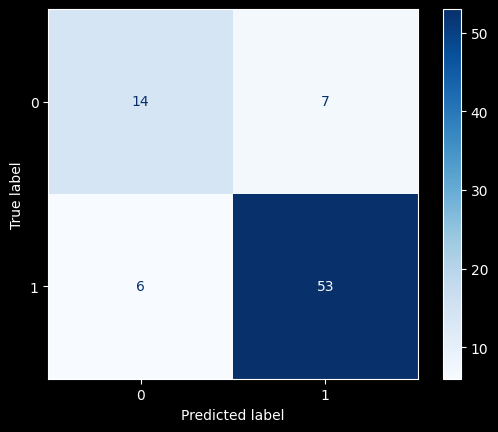

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=model.classes_)
disp.plot(cmap="Blues")

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

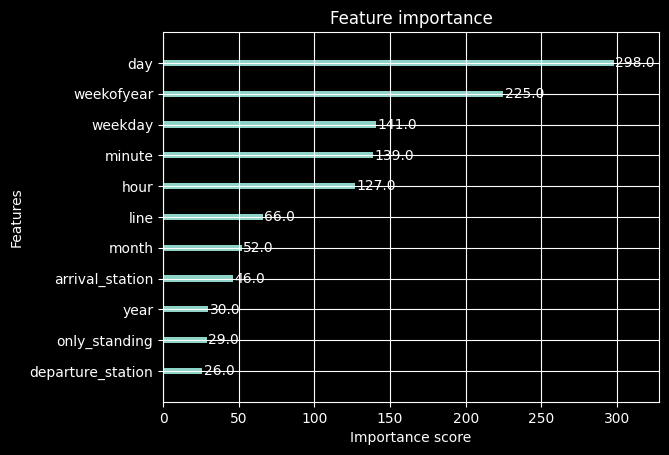

In [34]:
xgb.plot_importance(model)

## Model 2 - Model 1 with Optuna

In [35]:
import optuna as opt


def objective(trial):
    """The objective is to find the best parameters for the most accuracy in the model"""

    params = {
        'max_depth': trial.suggest_int('max_depth', 1, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0),
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'min_child_weight': trial.suggest_int('min_child_weight', 0, 10),
        'gamma': trial.suggest_float('gamma', 1e-8, 1e+3),
        'subsample': trial.suggest_float('subsample', 0.01, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.01, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0),
        'eval_metric': 'mlogloss'
    }

    # Fit the model
    optuna_model = xgb.XGBClassifier(**params)
    optuna_model.fit(x_train, y_train)

    # Make predictions
    y_pred = optuna_model.predict(x_test)

    # Evaluate predictions
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy


study = opt.create_study(direction="maximize")
study.optimize(objective, n_trials=750)

/home/sigurd/miniconda3/envs/ticket-inspection-ai-2/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2025-12-28 00:34:05,136] A new study created in memory with name: no-name-2dda785a-1bf6-4316-b858-dbbb80cfcfbd
[I 2025-12-28 00:34:05,399] Trial 0 finished with value: 0.7375 and parameters: {'max_depth': 1, 'learning_rate': 0.396617849236805, 'n_estimators': 442, 'min_child_weight': 3, 'gamma': 866.4208806092548, 'subsample': 0.5173083830869837, 'colsample_bytree': 0.29683222121520947, 'reg_alpha': 0.5072033937433574, 'reg_lambda': 0.6459330806268876}. Best is trial 0 with value: 0.7375.
[I 2025-12-28 00:34:05,470] Trial 1 finished with value: 0.7375 and parameters: {'max_depth': 4, 'learning_rate': 0.35851379220080387, 'n_estimators': 89, 'min_child_weight': 7, 'gamma': 630.3339269671734, 'subsample'

In [36]:
bparams = study.best_params
model_2 = xgb.XGBClassifier(**bparams)
model_2.fit(x_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.3728241019961394
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [37]:
preds_2 = model_2.predict(x_test)

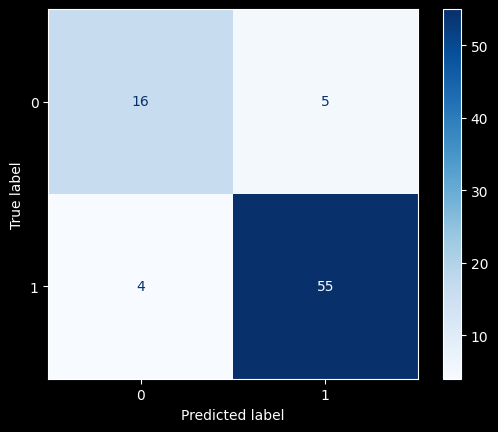

In [38]:
cm = confusion_matrix(y_true=y_test, y_pred=preds_2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_2.classes_)

disp.plot(cmap='Blues')

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

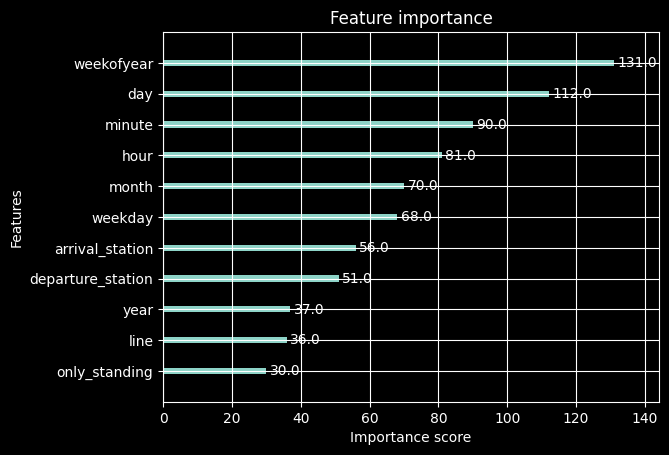

In [39]:
xgb.plot_importance(model_2)

In [40]:
accuracy_2 = accuracy_score(y_true=y_test, y_pred=preds_2)
print(f"Accuracy: {accuracy_2 * 100.0 :.2f}")

Accuracy: 88.75


# Save the best model

In [41]:
import os
import pickle
from datetime import UTC, datetime

# Model 2 will probably always be the best out of these two
dir_path = f"{PROJECT_ROOT}/models/{datetime.now(UTC).strftime("%Y%m%dT%H%M%S%z")}"
os.makedirs(dir_path, exist_ok=True)
model_2.save_model(f'{dir_path}/ticket-inspection-ai-model-{datetime.now(UTC).strftime("%Y%m%dT%H%M%S%z")}.pkl')

# Save categories
os.mkdir(dir_path + "/categories")
for col, cats in categories.items():
    with open(f'{dir_path}/categories/{col}.pkl', 'wb') as f:
        pickle.dump(cats, f)

/home/sigurd/miniconda3/envs/ticket-inspection-ai-2/lib/python3.13/site-packages/xgboost/sklearn.py:1028: UserWarning: [00:36:25] WARNING: /workspace/src/c_api/c_api.cc:1427: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  self.get_booster().save_model(fname)
